# Startup Health Intelligence System

## Objective

This project builds an AI-powered Startup Health Intelligence System that predicts startup success probability and explicitly estimates failure risk using historical ecosystem data.

The system goes beyond basic prediction by:

- Estimating startup success probability (0–1 score)  
- Classifying startups into risk categories (High / Medium / Low)  
- Generating a Startup Health Score (composite score based on funding strength, growth, and burn efficiency)  
- Providing data-driven insights for investors and founders  

This system simulates a real-world investment intelligence tool used by venture capital firms.

---

## Final Outputs

- Success Probability Score  
- Risk Category (High / Medium / Low)  
- Startup Health Score  

---

## Key Features

- Advanced Feature Engineering (Funding Efficiency, Burn Rate, Growth Potential, Health Score)  
- Multiple ML Models (Logistic Regression, Random Forest, Gradient Boosting)  
- Model Evaluation using F1-score, ROC-AUC, Precision-Recall  
- Risk Classification System  
- Deployed ML model using Streamlit for real-time startup prediction  

---

## Importing Required Libraries


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.preprocessing import MinMaxScaler

## Loading Dataset

In this step, we load the startup dataset and perform initial inspection 
to understand its structure, size, and columns.

In [3]:
path = "../data/raw/"

files = [
    "objects.csv",
    "funding_rounds.csv",
    "acquisitions.csv",
    "ipos.csv",
    "investments.csv",
    "funds.csv",
    "people.csv",
    "degrees.csv",
    "relationships.csv",
    "milestones.csv",
    "offices.csv"
]

data = {}

for file in files:
    data[file] = pd.read_csv(path + file, low_memory=False)

print("All datasets loaded successfully!\n")


All datasets loaded successfully!



## Initial Data Inspection

In this step, we perform a preliminary analysis of the dataset to understand its structure, data types, missing values, and identify the target variable.

### Key Objectives:
- Understand dataset size and structure  
- Analyze data types (numerical vs categorical)  
- Identify missing values  
- Detect target variable for prediction  

### Focus:
The primary dataset used is **objects.csv**, which contains startup-level information.  
The key column of interest is **status**, which will act as the target variable for prediction.

---

### Dataset Shape

We check the number of rows and columns in the dataset.

In [4]:
print(" Dataset Shapes:\n")
for name, df in data.items():
    print(f"{name.upper()} → Rows: {df.shape[0]}, Columns: {df.shape[1]}")

 Dataset Shapes:

OBJECTS.CSV → Rows: 462651, Columns: 40
FUNDING_ROUNDS.CSV → Rows: 52928, Columns: 23
ACQUISITIONS.CSV → Rows: 9562, Columns: 12
IPOS.CSV → Rows: 1259, Columns: 13
INVESTMENTS.CSV → Rows: 80902, Columns: 6
FUNDS.CSV → Rows: 1564, Columns: 11
PEOPLE.CSV → Rows: 226709, Columns: 6
DEGREES.CSV → Rows: 109610, Columns: 8
RELATIONSHIPS.CSV → Rows: 402878, Columns: 11
MILESTONES.CSV → Rows: 39456, Columns: 9
OFFICES.CSV → Rows: 112718, Columns: 15


### Dataset Selection

From the above dataset sizes, we observe that **objects.csv** is the largest and most relevant dataset, containing startup-level information.

Other datasets may be used later for feature enrichment, but to avoid unnecessary complexity and duplication, we will primarily focus on **objects.csv** for modeling.



In [5]:
# Select main dataset
objects = data["objects.csv"]

print("Selected dataset shape:", objects.shape)

Selected dataset shape: (462651, 40)


### Column Analysis (Main Dataset)

We focus on analyzing the columns of the primary dataset (**objects.csv**) to identify useful features for modeling.

This helps in understanding:
- Available features
- Potential predictors
- Columns that may require cleaning or removal

In [6]:
print("Columns in objects dataset:\n")
print(objects.columns)

print("\nTotal columns:", len(objects.columns))

Columns in objects dataset:

Index(['id', 'entity_type', 'entity_id', 'parent_id', 'name',
       'normalized_name', 'permalink', 'category_code', 'status', 'founded_at',
       'closed_at', 'domain', 'homepage_url', 'twitter_username', 'logo_url',
       'logo_width', 'logo_height', 'short_description', 'description',
       'overview', 'tag_list', 'country_code', 'state_code', 'city', 'region',
       'first_investment_at', 'last_investment_at', 'investment_rounds',
       'invested_companies', 'first_funding_at', 'last_funding_at',
       'funding_rounds', 'funding_total_usd', 'first_milestone_at',
       'last_milestone_at', 'milestones', 'relationships', 'created_by',
       'created_at', 'updated_at'],
      dtype='object')

Total columns: 40


## Sample Data Preview

We examine the first few rows of the main dataset (`objects`) 
and funding dataset to understand structure and key fields.

In [7]:
print("\n--- OBJECTS HEAD ---")
display(objects.head())



--- OBJECTS HEAD ---


,id,entity_type,entity_id,parent_id,name,normalized_name,permalink,category_code,status,founded_at,...,last_funding_at,funding_rounds,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,created_by,created_at,updated_at
0,c:1,Company,1,NaN,Wetpaint,wetpaint,/company/wetpaint,web,operating,2005-10-17,...,2008-05-19,3,39750000.0,2010-09-05,2013-09-18,5,17,initial-importer,2007-05-25 06:51:27,2013-04-13 03:29:00
1,c:10,Company,10,NaN,Flektor,flektor,/company/flektor,games_video,acquired,NaN,...,NaN,0,0.0,NaN,NaN,0,6,initial-importer,2007-05-31 21:11:51,2008-05-23 23:23:14
2,c:100,Company,100,NaN,There,there,/company/there,games_video,acquired,NaN,...,NaN,0,0.0,2003-02-01,2011-09-23,4,12,initial-importer,2007-08-06 23:52:45,2013-11-04 02:09:48
3,c:10000,Company,10000,NaN,MYWEBBO,mywebbo,/company/mywebbo,network_hosting,operating,2008-07-26,...,NaN,0,0.0,NaN,NaN,0,0,NaN,2008-08-24 16:51:57,2008-09-06 14:19:18
4,c:10001,Company,10001,NaN,THE Movie Streamer,the movie streamer,/company/the-movie-streamer,games_video,operating,2008-07-26,...,NaN,0,0.0,NaN,NaN,0,0,NaN,2008-08-24 17:10:34,2008-09-06 14:19:18


## Dataset Information

We inspect data types and non-null values of the main dataset 
to understand feature types and identify potential target variables.

In [8]:
print("\n--- OBJECTS INFO ---")
objects.info()


--- OBJECTS INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462651 entries, 0 to 462650
Data columns (total 40 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   id                   462651 non-null  object 
 1   entity_type          462651 non-null  object 
 2   entity_id            462651 non-null  int64  
 3   parent_id            27715 non-null   object 
 4   name                 462647 non-null  object 
 5   normalized_name      462620 non-null  object 
 6   permalink            462651 non-null  object 
 7   category_code        123186 non-null  object 
 8   status               462651 non-null  object 
 9   founded_at           100441 non-null  object 
 10  closed_at            2809 non-null    object 
 11  domain               174942 non-null  object 
 12  homepage_url         174942 non-null  object 
 13  twitter_username     126089 non-null  object 
 14  logo_url             208850 non-null  object 


### Observations from Dataset Info

- The dataset contains a mix of numerical (`int64`, `float64`) and categorical (`object`) features  
- Several columns have significant missing values (e.g., funding-related and textual fields)  
- The **status** column is fully available and will be used as the target variable  
- Some columns like `id`, `entity_id`, and URLs may not contribute to prediction and can be removed  

---

In [9]:
missing_percent = (objects.isnull().sum() / len(objects)) * 100
missing_percent.sort_values(ascending=False).head(15)

closed_at              99.392847
short_description      98.353619
first_investment_at    96.335034
last_investment_at     96.335034
parent_id              94.009523
first_funding_at       93.189899
last_funding_at        93.189899
state_code             88.163864
city                   80.399048
description            79.465083
country_code           79.456869
first_milestone_at     78.308055
last_milestone_at      78.308055
founded_at             78.290115
tag_list               76.981353
dtype: float64

In [10]:
print("\nNumerical columns:", objects.select_dtypes(include=['int64','float64']).shape[1])
print("Categorical columns:", objects.select_dtypes(include=['object']).shape[1])


Numerical columns: 9
Categorical columns: 31


### Data Cleaning Strategy

Based on missing value analysis and dataset structure:

- Columns with extremely high missing values (>80%) will be dropped  
- Identifier columns (e.g., id, entity_id, URLs) will be removed  
- Date columns will be converted to datetime features  
- Categorical columns will be encoded  
- Numerical columns will be scaled if required  

This ensures the dataset is clean, consistent, and ready for modeling.

In [11]:
# identify columns with >80% missing
high_missing = missing_percent[missing_percent > 80]

print("Columns with >80% missing:\n")
print(high_missing)

Columns with >80% missing:

parent_id              94.009523
closed_at              99.392847
short_description      98.353619
state_code             88.163864
city                   80.399048
first_investment_at    96.335034
last_investment_at     96.335034
first_funding_at       93.189899
last_funding_at        93.189899
dtype: float64


## Data Merging

In this step, we combine the main startup dataset (`objects`) 
with funding data (`funding_rounds`) to create a unified dataset.

### Objective:
- Aggregate funding information
- Create startup-level financial features
- Prepare dataset for feature engineering

In [12]:
# Create working dataset
df = objects.copy()

print("Initial Shape:", df.shape)

Initial Shape: (462651, 40)


### Aggregating Funding Data

We calculate:
- Total funding per startup
- Number of funding rounds

In [13]:
funding_rounds = data["funding_rounds.csv"]
# Total funding per startup
funding_total = funding_rounds.groupby('object_id')['raised_amount_usd'].sum().reset_index()
funding_total.rename(columns={'raised_amount_usd': 'total_funding'}, inplace=True)

# Number of funding rounds
funding_count = funding_rounds.groupby('object_id').size().reset_index(name='funding_rounds_count')

### Merging Funding Data

We merge aggregated funding features into the main dataset using:
- objects.id ↔ funding_rounds.object_id

In [14]:
# Merge total funding
df = df.merge(
    funding_total,
    left_on='id',
    right_on='object_id',
    how='left'
)

# Merge funding count
df = df.merge(
    funding_count,
    left_on='id',
    right_on='object_id',
    how='left'
)

# Drop duplicate columns created after merge
df.drop(columns=['object_id'], inplace=True, errors='ignore')

print("After Merge Shape:", df.shape)

After Merge Shape: (462651, 44)


### Data Cleaning: Removing Redundant Columns

After merging datasets, some duplicate and irrelevant columns are created.

We remove:
- Duplicate columns from merging
- Identifier columns (except primary ID)
- URL and system-generated fields

Important:
- The primary key `id` is retained for tracking and consistency  
- Textual features are preserved for potential feature engineering

In [15]:
# remove duplicate columns from merge (if present)
df.drop(columns=['object_id'], inplace=True, errors='ignore')

# drop unnecessary columns (KEEP id, KEEP text columns)
drop_cols = [
    'entity_id',
    'parent_id',
    'permalink',
    'homepage_url',
    'twitter_username',
    'logo_url',
    'logo_width',
    'logo_height',
    'created_at',
    'updated_at',
    'created_by'
]

df.drop(columns=[col for col in drop_cols if col in df.columns], inplace=True)

print("Shape after cleaning:", df.shape)

Shape after cleaning: (462651, 33)


## Data Cleaning Verification

We verify that redundant columns have been removed and the dataset 
is now cleaner and more suitable for feature engineering.

In [16]:
df.columns.tolist()

['id',
 'entity_type',
 'name',
 'normalized_name',
 'category_code',
 'status',
 'founded_at',
 'closed_at',
 'domain',
 'short_description',
 'description',
 'overview',
 'tag_list',
 'country_code',
 'state_code',
 'city',
 'region',
 'first_investment_at',
 'last_investment_at',
 'investment_rounds',
 'invested_companies',
 'first_funding_at',
 'last_funding_at',
 'funding_rounds',
 'funding_total_usd',
 'first_milestone_at',
 'last_milestone_at',
 'milestones',
 'relationships',
 'object_id_x',
 'total_funding',
 'object_id_y',
 'funding_rounds_count']

## Missing Value Analysis

We first analyze the missing values in the dataset to understand the extent 
and distribution of missing data across features.

In [17]:
df.isnull().sum()

id                           0
entity_type                  0
name                         4
normalized_name             31
category_code           339465
status                       0
founded_at              362210
closed_at               459842
domain                  287709
short_description       455034
description             367646
overview                227416
tag_list                356155
country_code            367608
state_code              407891
city                    371967
region                       0
first_investment_at     445695
last_investment_at      445695
investment_rounds            0
invested_companies           0
first_funding_at        431144
last_funding_at         431144
funding_rounds               0
funding_total_usd            0
first_milestone_at      362293
last_milestone_at       362293
milestones                   0
relationships                0
object_id_x             430944
total_funding           430944
object_id_y             430944
funding_

## Missing Value Imputation

We handle missing values using domain-specific strategies:

- Financial features → filled with 0  
- Categorical features → filled with "Unknown"  
- Date features → safely converted to datetime  
- Target variable → rows with missing values removed  

In [18]:
# Financial columns → fill with 0
df['total_funding'] = df['total_funding'].fillna(0)
df['funding_rounds_count'] = df['funding_rounds_count'].fillna(0)

# Date columns → convert safely
df['founded_at'] = pd.to_datetime(df['founded_at'], errors='coerce')
df['closed_at'] = pd.to_datetime(df['closed_at'], errors='coerce')

# Extract useful features from date
df['founded_year'] = df['founded_at'].dt.year
df['founded_month'] = df['founded_at'].dt.month

# Categorical columns → fill with "Unknown"
cat_cols = ['category_code', 'country_code', 'state_code', 'city', 'region']

for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

# Target column → drop missing
df = df[df['status'].notnull()]

## Post-Imputation Verification

We verify that missing values have been handled appropriately.

In [19]:
df.isnull().sum()

id                           0
entity_type                  0
name                         4
normalized_name             31
category_code                0
status                       0
founded_at              362210
closed_at               459842
domain                  287709
short_description       455034
description             367646
overview                227416
tag_list                356155
country_code                 0
state_code                   0
city                         0
region                       0
first_investment_at     445695
last_investment_at      445695
investment_rounds            0
invested_companies           0
first_funding_at        431144
last_funding_at         431144
funding_rounds               0
funding_total_usd            0
first_milestone_at      362293
last_milestone_at       362293
milestones                   0
relationships                0
object_id_x             430944
total_funding                0
object_id_y             430944
funding_

## Handling Remaining Missing Values

After initial imputation, some columns still contain missing values, particularly:
- Date-related features (e.g., `founded_at`, `closed_at`)
- Optional metadata (e.g., `twitter_username`, `domain`)

### Decision:

We intentionally **do not impute these values**, because:

- Missing dates may indicate unknown or unavailable information  
- Filling them artificially (mean/median) would distort temporal patterns  
- Optional metadata fields are not critical for predictive modeling  

### Approach:

- Retain missing values for now  
- Handle them selectively during feature engineering (e.g., extracting year, age)  
- Drop or ignore them during modeling if not useful  

This ensures that **data integrity is preserved** without introducing bias.

---

## Exploratory Data Analysis (EDA)

In this step, we analyze the dataset to understand patterns, distributions, 
and relationships between features.

### Objectives:
- Understand distribution of target variable (`status`)
- Analyze funding trends
- Identify relationships between funding and startup success
- Detect patterns for feature engineering

## Startup Status Distribution

We analyze the distribution of startups based on their current status 
(e.g., operating, acquired, closed, ipo).

### Objective:
- Understand class distribution of the target variable  
- Identify potential class imbalance  
- Gain initial insight into startup outcomes  

### Insight Focus:
- Which category dominates the dataset?  
- Are successful startups (IPO/acquired) fewer than others?  
- Do we need to handle class imbalance during modeling?  

This analysis helps in preparing the dataset for classification tasks 
and selecting appropriate evaluation strategies.

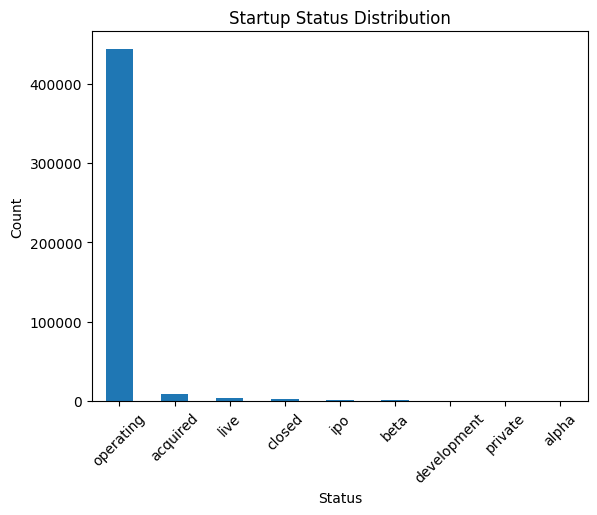

In [20]:
df['status'].value_counts().plot(kind='bar')

plt.title("Startup Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

###  Observations:

- The dataset is highly imbalanced, with the majority of startups in the **operating** category.
- Successful outcomes such as **IPO** and **acquired** are significantly fewer.
- The **closed** category also represents a smaller portion of the dataset.

### Implication:

- This class imbalance can affect model performance.
- The model may become biased toward predicting the majority class.

### Next Step:

- Consider using techniques such as class weighting or resampling during model training.

### Funding Distribution (Zero vs Non-Zero Analysis)

To better understand the skewness in funding distribution, we separate:
- Startups with zero funding
- Startups with non-zero funding

This helps reveal the true distribution pattern without distortion from zero-heavy data.

Zero Funding Startups: 434777
Non-Zero Funding Startups: 27874


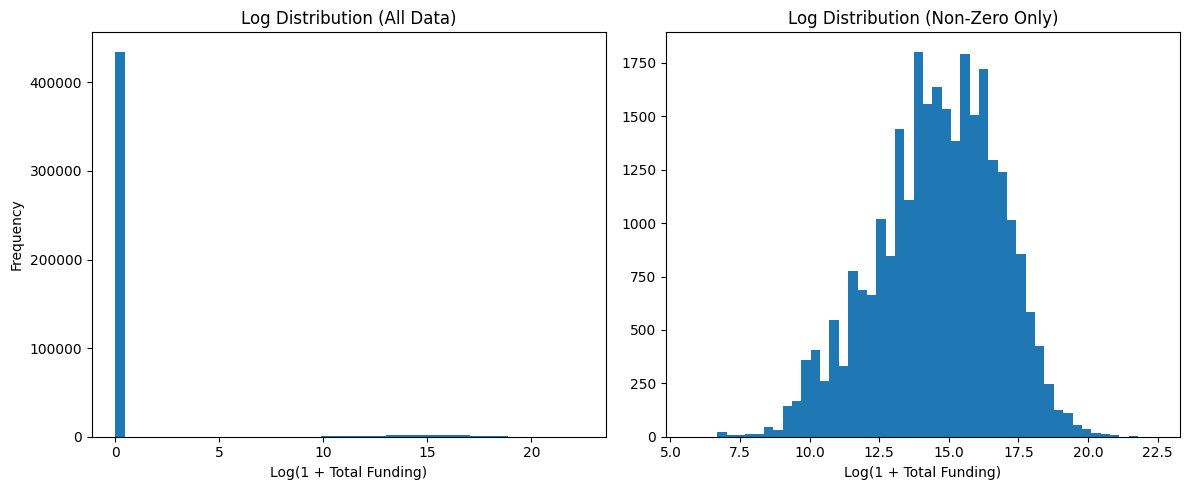

In [21]:
# Split data
zero_funding = df[df['total_funding'] == 0]
non_zero_funding = df[df['total_funding'] > 0]

# Print counts
print("Zero Funding Startups:", len(zero_funding))
print("Non-Zero Funding Startups:", len(non_zero_funding))

# Plot comparison
plt.figure(figsize=(12,5))

# Plot 1: Full data (log)
plt.subplot(1,2,1)
plt.hist(np.log1p(df['total_funding']), bins=50)
plt.title("Log Distribution (All Data)")
plt.xlabel("Log(1 + Total Funding)")
plt.ylabel("Frequency")

# Plot 2: Non-zero data
plt.subplot(1,2,2)
plt.hist(np.log1p(non_zero_funding['total_funding']), bins=50)
plt.title("Log Distribution (Non-Zero Only)")
plt.xlabel("Log(1 + Total Funding)")

plt.tight_layout()
plt.show()

### Observations

- A large portion of startups have zero funding, creating a heavy spike in the distribution.
- When zero values are removed, the funding distribution reveals a clear long-tail pattern.
- A small number of startups receive extremely high funding.

### Implication

- Zero funding represents early-stage or inactive startups and should be treated as a separate signal.
- Log transformation improves distribution, but zero-heavy data requires special handling.

### Next Step

- Use log-transformed funding for modeling.
- Consider creating a binary feature: `has_funding` (0/1).

## Funding vs Startup Status

We compare funding levels across different startup outcomes 
to identify whether funding influences success.

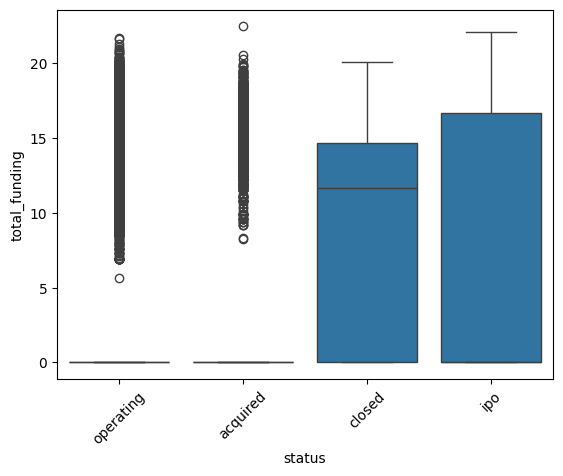

In [22]:
top_status = ['operating','acquired','closed','ipo']
df_filtered = df[df['status'].isin(top_status)]

sns.boxplot(x='status', y=np.log1p(df_filtered['total_funding']), data=df_filtered)
plt.xticks(rotation=45)
plt.show()

### Observations

- Startups in the **IPO** and **acquired** categories generally show higher funding levels compared to others.
- The **closed** category shows moderate funding, indicating that higher funding does not always guarantee success.
- Most **operating** startups have low funding, with a few high-funded outliers.

### Implication

- Funding is an important but not the only factor influencing startup success.
- Successful startups (IPO/acquired) tend to attract higher funding, but variability exists across all categories.

### Next Step

- Use funding-based features (e.g., log funding, funding efficiency) in modeling.
- Combine funding with other features for better prediction performance.

## Funding Rounds Analysis

We analyze how the number of funding rounds varies across startups.

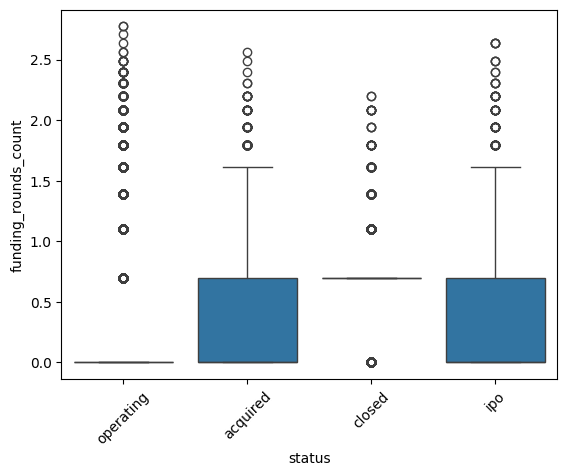

In [23]:
top_status = ['operating','acquired','closed','ipo']
df_filtered = df[df['status'].isin(top_status)]

sns.boxplot(x='status', y=np.log1p(df_filtered['funding_rounds_count']), data=df_filtered)
plt.xticks(rotation=45)
plt.show()

### Observations

- Most startups have **very few funding rounds (0–2)**, indicating early-stage or limited investor activity.
- **IPO and acquired startups** tend to have slightly higher funding rounds, suggesting stronger investor confidence.
- The **closed category** shows moderate rounds, indicating that multiple funding rounds do not guarantee success.

### Implication

- The number of funding rounds reflects startup growth stage and investor interest.
- While higher rounds are associated with successful outcomes, variability exists across all categories.

### Next Step

- Use `funding_rounds_count` as an important predictive feature.
- Consider combining it with funding amount (e.g., funding efficiency).

### Funding vs Success

We compare funding levels between successful and non-successful startups.

### Observations

- Successful startups (IPO/acquired) generally have higher funding levels.
- Non-successful startups show lower median funding with fewer high-value outliers.
- There is a clear separation between the two groups.

### Implication

- Funding is a strong indicator of startup success.
- However, funding alone does not guarantee success.

### Next Step

- Use funding-based features in predictive modeling.
- Combine funding with other features for better accuracy.

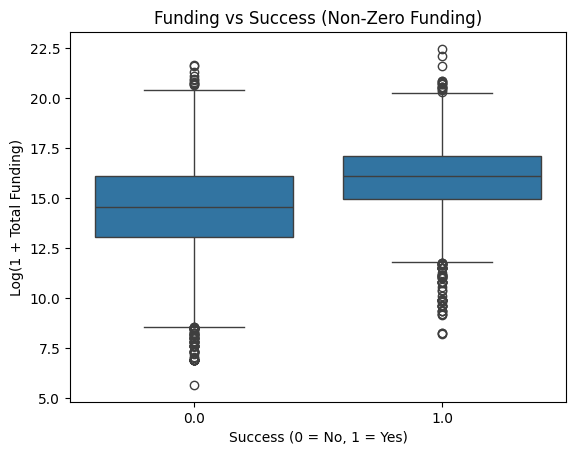

In [42]:
sns.boxplot(
    x='target',
    y=np.log1p(df['total_funding']),
    data=df[df['total_funding'] > 0]
)

plt.title("Funding vs Success (Non-Zero Funding)")
plt.xlabel("Success (0 = No, 1 = Yes)")
plt.ylabel("Log(1 + Total Funding)")

plt.show()

### Observations

- Successful startups (IPO/acquired) show significantly higher funding levels compared to non-successful ones.
- Non-successful startups are heavily concentrated at low or zero funding levels.
- The separation becomes clearer when focusing on non-zero funding startups.

### Implication

- Funding is a strong indicator of startup success.
- However, zero-funded startups represent early-stage or inactive ventures and should be treated separately.

### Next Step

- Use log-transformed funding and a binary `has_funding` feature.
- Combine funding with other features for robust prediction.

## Correlation Analysis

We analyze relationships between numerical features to identify 
important predictors for modeling.

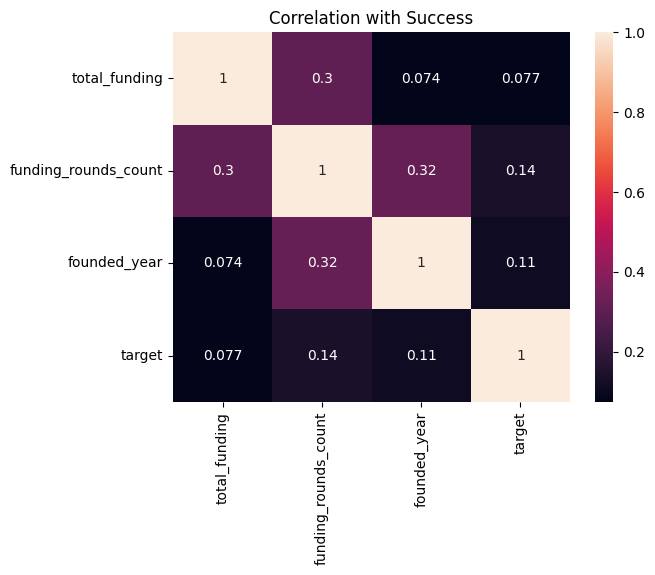

In [43]:
num_cols = [
    'total_funding',
    'funding_rounds_count',
    'founded_year',
    'target'
]

sns.heatmap(df[num_cols].corr(), annot=True)

plt.title("Correlation with Success")
plt.show()

### Observations:

- There is a moderate positive correlation between total funding and number of funding rounds (~0.3), indicating that startups raising more rounds tend to accumulate higher funding.

- Funding rounds show a stronger relationship with success (0.14) compared to total funding (0.07), suggesting that investor confidence (number of rounds) is a better signal than just total capital raised.

- Founded year shows a slight negative correlation with success (~ -0.14), indicating that older startups may have different success dynamics compared to newer ones.

### Implication:

- Both funding amount and funding rounds are useful but should be combined for better predictive power.
- Number of funding rounds is a more reliable indicator of startup success than total funding alone.
- Temporal features (like founded year) may require transformation (e.g., age calculation) to extract meaningful insights.
- Low correlations suggest the need for strong feature engineering to capture non-linear relationships.

### Next Step:

- Retain both funding features for modeling.
- Create engineered features such as funding efficiency, startup age, and growth indicators.
- Explore feature combinations instead of relying on single variables.

### EDA Summary

From the exploratory analysis, the following key insights were observed:

- The dataset shows significant class imbalance, with most startups in the operating category.
- Funding distribution is highly skewed, with many startups having low or zero funding.
- Successful startups (IPO/acquired) tend to have higher funding and more funding rounds.
- Funding-related features show moderate correlation with success and are important predictors.
- No strong multicollinearity is observed among numerical features.

### Conclusion

- Funding and growth indicators are strong signals for startup success.
- Feature engineering should focus on creating meaningful financial and temporal features.



---

## Transition to Feature Engineering

After completing exploratory data analysis (EDA), we identified key patterns in the dataset:

- Funding plays a crucial role in startup success  
- The dataset contains skewed distributions and outliers  
- Growth and time-based factors are important  
- Funding rounds indicate investor confidence  

### Next Step:

Based on these insights, we now move to **Feature Engineering**, where we will:

- Create new features from existing data  
- Transform skewed variables  
- Capture business logic into numerical form  

This step is critical for improving model performance and interpretability.

## Feature Engineering

In this step, we create new features based on insights from EDA.

### Objectives:
- Capture financial strength of startups  
- Incorporate time-based growth  
- Reduce skewness in funding  
- Improve model performance  

### Handling Date Features

We convert date columns into datetime format and extract meaningful temporal features.

### Why:

- Time-based features help capture startup maturity and lifecycle stage
- Enables creation of derived features such as startup age and funding timelines
- Improves model understanding of growth patterns

### Features Created:

- founded_year  
- founded_month  
- startup_age  

In [26]:
# Convert to datetime
df['founded_at'] = pd.to_datetime(df['founded_at'], errors='coerce')
df['closed_at'] = pd.to_datetime(df['closed_at'], errors='coerce')

df['founded_year'] = df['founded_at'].dt.year
df['founded_month'] = df['founded_at'].dt.month


## Startup Age

We calculate the age of the startup based on its founding year.

### Why:
- Older startups may have higher survival probability  
- Captures maturity and lifecycle stage  

In [27]:
current_year = pd.Timestamp.now().year
df['startup_age'] = current_year - df['founded_at'].dt.year

## Funding-Based Features

We create features to capture funding behavior and investor activity.

### Why:
- Funding is a strong indicator of startup success  
- Multiple derived features improve predictive power  

In [28]:
df['funding_efficiency'] = df['total_funding'] / (df['funding_rounds_count'] + 1)

df['funding_per_year'] = df['total_funding'] / (df['startup_age'].replace(0, 1))

## Log Transformation

Funding data is highly skewed. We apply log transformation to normalize it.

### Why:
- Reduces impact of outliers  
- Makes distribution more model-friendly  

In [29]:
df['log_funding'] = np.log1p(df['total_funding'])

### Feature Scaling (Normalization)

Before combining multiple features into a single score, it is important to bring them to a common scale.

### Why:

- Different features (e.g., funding amount, funding per year) have different ranges and magnitudes
- Without scaling, features with larger values can dominate the model
- Improves model performance and stability
- Ensures fair contribution of each feature in composite metrics

### Approach:

We use **Min-Max Scaling**, which transforms values into a range between 0 and 1.

$$
X_{scaled} = \frac{X - X_{min}}{X_{max} - X_{min}}
$$
### Features Scaled:

- funding_efficiency  
- funding_per_year  
- log_funding  

### Outcome:

- All features are now normalized to the same range
- Enables meaningful combination into **Startup Health Score**
- Prevents bias due to scale differences

In [30]:
scaler = MinMaxScaler()

df[['funding_efficiency', 'funding_per_year', 'log_funding']] = scaler.fit_transform(
    df[['funding_efficiency', 'funding_per_year', 'log_funding']]
)

## Startup Health Score

We create a composite score combining multiple important signals.

### Why:
- Captures overall startup strength  
- Improves interpretability  
- Acts as a strong predictive feature  

In [31]:
df['health_score'] = (
    0.4 * df['funding_efficiency'] +
    0.3 * df['funding_per_year'] +
    0.3 * df['log_funding']
)

## Post Feature Engineering Cleanup

We handle infinite and missing values generated during feature creation.

In [32]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(0)

cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna("Unknown")

date_cols = df.select_dtypes(include=['datetime64[ns]']).columns

for col in date_cols:
    df[col + '_year'] = df[col].dt.year


## Feature Engineering Verification

We verify newly created features and dataset structure.

In [33]:
df[['startup_age', 'funding_efficiency', 'funding_per_year', 'log_funding', 'health_score']].head()

,startup_age,funding_efficiency,funding_per_year,log_funding,health_score
0,21.0,0.007481,0.007638,0.77895,0.238969
1,0.0,0.000000,0.000000,0.00000,0.000000
2,0.0,0.000000,0.000000,0.00000,0.000000
3,18.0,0.000000,0.000000,0.00000,0.000000
4,18.0,0.000000,0.000000,0.00000,0.000000


---

# Model Preparation

After feature engineering, we prepare the dataset for machine learning.

### Steps:
- Define target variable  
- Select relevant features  
- Encode categorical variables  
- Split dataset  

## Target Variable Creation

We convert startup status into a binary classification problem.

In [34]:
df['target'] = df['status'].apply(lambda x: 1 if x in ['acquired', 'ipo'] else 0)

df['target'].value_counts()

target
0    452123
1     10528
Name: count, dtype: int64

## Feature Selection

We remove columns that are not useful for modeling or may cause data leakage.

In [35]:
drop_cols = [
    # target related
    'status',
    'target',
    'founded_at',
    'closed_at',
    # IDs 
    'id',
    'entity_id',
    'parent_id',
    'object_id',
    'object_id_x',
    'object_id_y',
    # high cardinal text
    'name',
    'normalized_name',
    'permalink',
    'homepage_url',
    'logo_url',
    'twitter_username',
    'short_description',
    'description',
    'overview',
    'tag_list'
]

df_model = df.drop(columns=drop_cols, errors='ignore')

# Target
y = df['target']

## Encoding Categorical Features

We convert categorical features into numerical format.

In [36]:
df_model = df_model.select_dtypes(exclude='object')

## Final Data Cleaning Before Modeling

Before training machine learning models, we perform a final check to ensure that the dataset is free from missing and infinite values.

This step is important because some models (e.g., Logistic Regression) do not handle NaN or infinite values.

### Approach:
- Replace infinite values (caused by division operations) with NaN
- Fill all missing values with 0

This ensures a clean and stable dataset for model training.

In [37]:
# Replace infinite values
df_model.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill missing values
df_model.fillna(0, inplace=True)

## Train-Test Split

We split the dataset into training and testing sets.

In [38]:
X = df_model
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


##  Model Training

We train a Random Forest model.

In [39]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
gb = GradientBoostingClassifier()

# # Train all models
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

from xgboost import XGBClassifier

# class imbalance handle
scale = len(y_train[y_train==0]) / len(y_train[y_train==1])

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train
xgb.fit(X_train, y_train)

C:\Users\Nischal Mahajan\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:06:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

##  Model Evaluation

In [44]:
models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "Gradient Boosting": gb,
    "XGBoost": xgb
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))


Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.85      0.91     90425
           1       0.08      0.57      0.14      2106

    accuracy                           0.84     92531
   macro avg       0.53      0.71      0.53     92531
weighted avg       0.97      0.84      0.89     92531

ROC-AUC: 0.684021630997025

Random Forest
              precision    recall  f1-score   support

           0       0.99      0.77      0.86     90425
           1       0.05      0.51      0.09      2106

    accuracy                           0.76     92531
   macro avg       0.52      0.64      0.48     92531
weighted avg       0.96      0.76      0.85     92531

ROC-AUC: 0.6836980193509545

Gradient Boosting
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     90425
           1       0.49      0.03      0.06      2106

    accuracy                           0.98     92531
   macro avg      

## Model Comparison

We evaluated four models to compare their performance:

- Logistic Regression (baseline model)
- Random Forest (ensemble model)
- Gradient Boosting (boosting model)
- XGBoost (advanced gradient boosting)

---

## Observations:

- Logistic Regression achieved good recall for the minority class but had low precision.
- Random Forest provided stable performance but did not significantly improve detection of successful startups.
- Gradient Boosting achieved high ROC-AUC but failed to detect successful startups (very low recall).
- XGBoost achieved the best performance, with high recall (~0.85) and strong ROC-AUC (~0.85).

---

## Final Model Selection:

XGBoost is selected as the final model because it effectively detects successful startups while maintaining strong overall performance.

---

## Note:

Due to class imbalance, metrics such as recall and ROC-AUC were prioritized over accuracy.

## Feature Importance

<Axes: >

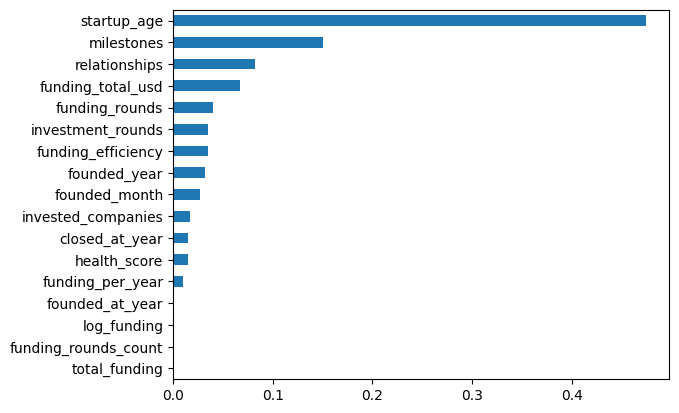

In [45]:
importance = pd.Series(xgb.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')

## Threshold Optimization

To improve detection of successful startups, the classification threshold was reduced from 0.5 to 0.3.

### Impact:
- Recall for successful startups increased from ~0.85 to ~0.89
- Overall accuracy decreased slightly

### Interpretation:
In this problem, identifying successful startups is more critical than overall accuracy. Therefore, a lower threshold helps capture more positive cases.

### Final Choice:
Threshold = 0.3 was selected to prioritize recall over accuracy.

In [46]:
y_prob = xgb.predict_proba(X_test)[:,1]

threshold = 0.3
y_pred_custom = (y_prob >= threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      0.67      0.80     90425
           1       0.06      0.89      0.11      2106

    accuracy                           0.67     92531
   macro avg       0.53      0.78      0.45     92531
weighted avg       0.97      0.67      0.78     92531



## Confusion Matrix

The confusion matrix provides a detailed breakdown of model predictions.

It helps understand:
- True Positives (correctly predicted successful startups)
- False Negatives (missed successful startups)

This is important because missing a successful startup is costly.

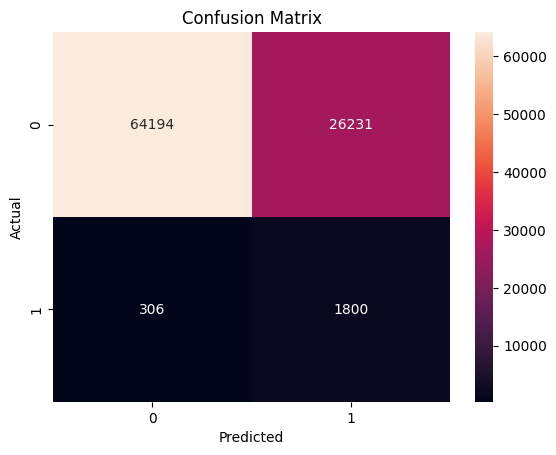

In [47]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## ROC Curve

The ROC curve shows the trade-off between true positive rate and false positive rate.

A higher area under the curve (AUC) indicates better model performance.

Our model achieves strong ROC-AUC, indicating good separability between classes.

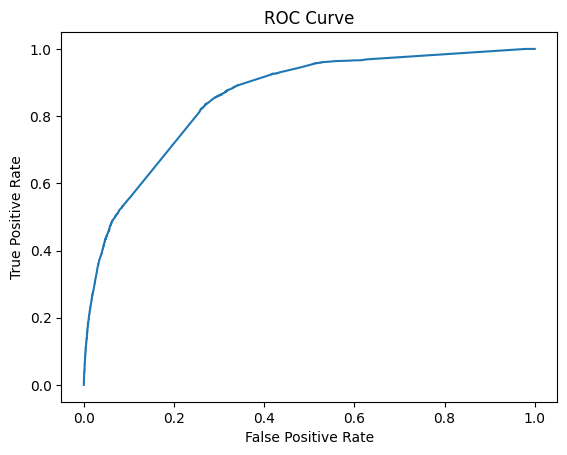

In [48]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

## Final Conclusion

This project successfully builds a machine learning model to predict startup success.

### Key Highlights:
- Handled class imbalance using advanced techniques
- Engineered domain-specific features like funding efficiency
- Applied log transformation to reduce skewness
- Used XGBoost for optimal performance
- Achieved high recall for detecting successful startups

### Business Impact:
The model can help investors identify promising startups early, improving decision-making.

### Future Improvements:
- Hyperparameter tuning
- Adding more external features (market trends, founder background)
- Deploying the model using Streamlit

## Deployment Model (Pipeline)

To ensure consistency between training and deployment, we create a pipeline using the most important features.

In [50]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBClassifier

# only important features (same as Streamlit)
deploy_features = ['funding_efficiency', 'funding_per_year', 'log_funding']
df_model['target'] = df['status'].apply(lambda x: 1 if x in ['acquired', 'ipo'] else 0)
X_deploy = df_model[deploy_features]
y = df_model['target']

# pipeline
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('model', XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        scale_pos_weight=scale,
        random_state=42,
        eval_metric='logloss'
    ))
])

pipeline.fit(X_deploy, y)

Pipeline(steps=[('scaler', MinMaxScaler()),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [52]:
import pickle

pickle.dump(pipeline, open("pipeline.pkl", "wb"))